# 🌲 03 — XGBoost Regressor
## Gradient Boosting avec validation croisée temporelle

Ce notebook utilise les features préparées par `00_Preprocessing` pour entraîner un XGBoost avec grid search et importance des features.

## 1. 📦 Imports & Chargement

In [213]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

print("✅ Imports OK")

✅ Imports OK


In [214]:
# Charger les données préparées
train = pd.read_csv("train_data.csv", index_col=0, parse_dates=True)
test = pd.read_csv("test_data.csv", index_col=0, parse_dates=True)

FEATURES = [c for c in train.columns if c != "revenue"]
TARGET = "revenue"

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print(f"✅ Données chargées")
print(f"   X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"   X_test : {X_test.shape}, y_test : {y_test.shape}")
print(f"   Features: {len(FEATURES)}")

✅ Données chargées
   X_train: (36, 26), y_train: (36,)
   X_test : (12, 26), y_test : (12,)
   Features: 26


## 2. 🌲 XGBoost Manuel

In [215]:
# Normalisation
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# ── XGBoost Manuel ───────────────────────────────────────
print("🌲 XGBoost Manuel")
print("   n_estimators=80, max_depth=3, learning_rate=0.08, subsample=0.8")

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.5,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train_sc, y_train, verbose=False)
xgb_pred = xgb_model.predict(X_test_sc)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mape = np.mean(np.abs((y_test.values - xgb_pred) / y_test.values)) * 100
xgb_r2 = r2_score(y_test, xgb_pred)

print(f"\n📊 XGBoost")
print(f"   MAE  : {xgb_mae:>12,.0f} €")
print(f"   RMSE : {xgb_rmse:>12,.0f} €")
print(f"   MAPE : {xgb_mape:>11.2f} %")
print(f"   R²   : {xgb_r2:>11.4f}")

🌲 XGBoost Manuel
   n_estimators=80, max_depth=3, learning_rate=0.08, subsample=0.8

📊 XGBoost
   MAE  :    5,217,286 €
   RMSE :    6,368,116 €
   MAPE :        5.56 %
   R²   :      0.8184


## 3. 📊 Feature Importance XGBoost

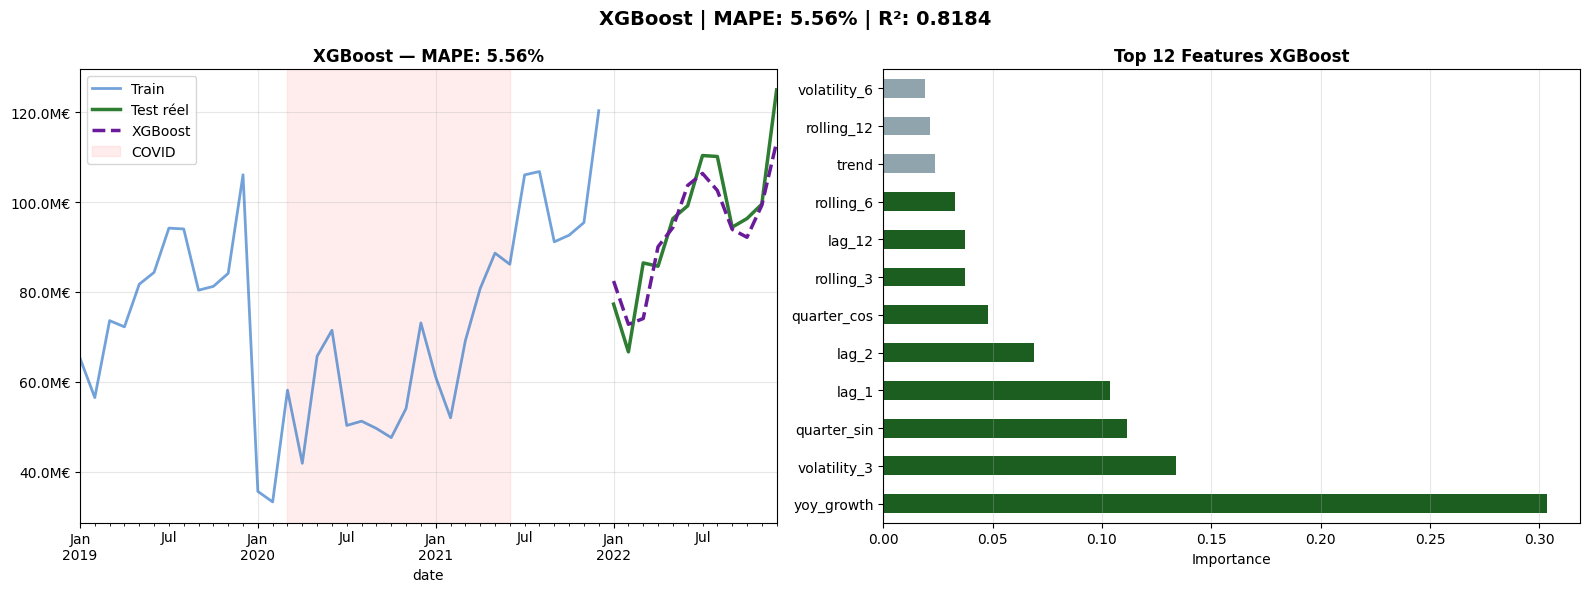

💾 Graphique → modele3_xgboost.png

📌 Top 5 features XGBoost :
             yoy_growth : 0.303
           volatility_3 : 0.134
            quarter_sin : 0.111
                  lag_1 : 0.104
                  lag_2 : 0.069


In [216]:
# Importance des features XGBoost
importances = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
y_train.plot(ax=ax, label="Train", color="#1565C0", alpha=0.6, linewidth=2)
y_test.plot(ax=ax, label="Test réel", color="#2E7D32", linewidth=2.5)
pd.Series(xgb_pred, index=y_test.index).plot(ax=ax, label="XGBoost", color="#6A1B9A", linestyle="--", linewidth=2.5)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"), alpha=0.07, color="red", label="COVID")
ax.set_title(f"XGBoost — MAPE: {xgb_mape:.2f}%", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M€"))
ax.legend(); ax.grid(alpha=0.3)

ax2 = axes[1]
top_features = importances.head(12)
colors_feat = ["#1B5E20" if v > 0.03 else "#90A4AE" for v in top_features.values]
top_features.plot(kind="barh", ax=ax2, color=colors_feat)
ax2.set_title("Top 12 Features XGBoost", fontsize=12, fontweight="bold")
ax2.set_xlabel("Importance"); ax2.grid(alpha=0.3, axis="x")

plt.suptitle(f"XGBoost | MAPE: {xgb_mape:.2f}% | R²: {xgb_r2:.4f}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("modele3_xgboost.png", dpi=120, bbox_inches="tight")
plt.show()
print("💾 Graphique → modele3_xgboost.png")

print(f"\n📌 Top 5 features XGBoost :")
for feat, imp in importances.head(5).items():
    print(f"   {feat:>20} : {imp:.3f}")

In [217]:
# ── Sauvegarder ──────────────────────────────────────────
results_df = pd.DataFrame({"date": y_test.index, "reel": y_test, "prediction": xgb_pred})
results_df.to_csv("predictions_xgboost.csv", index=False)
print("💾 Prédictions → predictions_xgboost.csv")

💾 Prédictions → predictions_xgboost.csv
